# Python API Walkthrough of Alpha/Beta Rhythms

This notebook reproduces, step for step, the
[GUI Tutorial of Alpha/Beta Rhythms](https://jonescompneurolab.github.io/textbook/content/06_alpha_beta/gui.html)
using the `hnn_core` Python API instead of the HNN GUI. Section numbers
below (3-7) match the section numbers of the GUI tutorial so that the two
can be read side by side. We recommend reading the GUI tutorial's
[Section 1: Background](https://jonescompneurolab.github.io/textbook/content/06_alpha_beta/gui.html#toc-1)
first, since the scientific motivation is not repeated here in full.

In brief: this tutorial is based on results from Jones et al. (2009), where
spontaneous (pre-stimulus) alpha (7-14 Hz) and beta (15-29 Hz) rhythms of
the SI mu-complex were recorded with MEG. The model reproduces these
rhythms with a combination of nearly-synchronous ~10 Hz rhythmic drives
delivered through the proximal and distal projection pathways of a
biophysical cortical column model. We will:

1. Simulate rhythmic **proximal**-only input (alpha only).
2. Simulate rhythmic **distal**-only input (alpha only).
3. Simulate **combined** proximal and distal input (the alpha/beta complex),
   including averaging jittered trials and checking spiking activity.
4. Adjust drive parameters to explore how relative strength, synchrony,
   and timing of the two drives change the expression of alpha versus
   beta rhythms, and how excessive drive strength produces
   non-physiological high-frequency spiking activity.

In the GUI tutorial, the four simulations of Sections 4-6 are configured by
loading pre-made parameter files (`OnlyRhythmicProx.json`,
`OnlyRhythmicDist.json`, `AlphaAndBeta.json`, and
`AlphaAndBetaJitter50.json`) downloaded from the
[hnn-data repository](https://github.com/jonescompneurolab/hnn-data/tree/main/workshops/alpha_beta_gui_walkthrough).
Here, instead of loading those files into the GUI, we call
`Network.add_bursty_drive()` directly with the exact same parameter values
that those files contain, so that the two workflows are numerically
equivalent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import psutil

import hnn_core
from hnn_core import jones_2009_model, simulate_dipole, MPIBackend, JoblibBackend
from hnn_core.viz import (
    plot_dipole,
    plot_tfr_morlet,
    plot_spikes_hist,
    plot_spikes_raster,
)

## 3. Setting Initial Simulation and Visualization Parameters

In the GUI, Section 3 has us change several default parameters *before*
running any simulations:

1. `Name` -- not needed here, since each simulation just gets its own
   Python variable name.
2. `tstop (ms)` = `700` -- in the API this is simply the `tstop` argument
   we pass to `simulate_dipole()` below.
3. `Dipole Smoothing` = `0` -- i.e., *no* smoothing. The API applies no
   smoothing unless we explicitly call the `.smooth()` method on a
   `Dipole` object, so there is nothing to change here.
4. `Min Spectral Frequency (Hz)` = `5` and `Max Spectral Frequency (Hz)` =
   `40` -- in the API this is the `freqs` array we pass to
   `plot_tfr_morlet()`.
5. `Cores` -- in the API, this is the `n_procs` argument of `MPIBackend`
   (or `n_jobs` of `JoblibBackend`). As in the GUI instructions, we set
   this to one less than the number of physical CPU cores available.

We also define a few small helper functions that reproduce the GUI's
`Drive-Dipole-Spectrogram (3x1)` and `Drive-Spikes (2x1)` visualization
layouts, since we will reuse them throughout this notebook.

In [2]:
n_procs = max(1, psutil.cpu_count(logical=False) - 1)
print(f'Using {n_procs} cores for parallel simulation')

tstop = 700.0  # ms
freqs = np.arange(5, 40, 1)  # Hz; matches "Min/Max Spectral Frequency"

# Colors matching the GUI convention: proximal drive ("bursty1") in red,
# distal drive ("bursty2") in green.
drive_colors = {'bursty1': 'r', 'bursty2': 'g'}

Using 7 cores for parallel simulation


In [3]:
def plot_drive_and_dipole(net, dpl, tmin=0, tmax=tstop, title=None):
    """Drive histogram + aggregate dipole waveform (c.f. GUI Figure 7)."""
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                              constrained_layout=True)
    plot_spikes_hist(net.cell_response, ax=axes[0], color=drive_colors,
                      show=False)
    axes[0].set_title('External drives')
    plot_dipole(dpl, ax=axes[1], layer='agg', tmin=tmin, tmax=tmax,
                average=isinstance(dpl, list) and len(dpl) > 1,
                color='b', show=False)
    axes[1].set_title('Aggregate current dipole')
    if title is not None:
        fig.suptitle(title)
    plt.show()
    return fig


def plot_drive_dipole_spectrogram(net, dpl, freqs=freqs, tmin=0, tmax=tstop,
                                   title=None):
    """Drive histogram + dipole waveform + TFR spectrogram, i.e. the
    GUI's 'Drive-Dipole-Spectrogram (3x1)' layout (c.f. GUI Figure 8)."""
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 9),
                              constrained_layout=True)
    plot_spikes_hist(net.cell_response, ax=axes[0], color=drive_colors,
                      show=False)
    axes[0].set_title('External drives')
    plot_dipole(dpl, ax=axes[1], layer='agg', tmin=tmin, tmax=tmax,
                average=isinstance(dpl, list) and len(dpl) > 1,
                color='b', show=False)
    axes[1].set_title('Aggregate current dipole')
    plot_tfr_morlet(dpl, freqs, n_cycles=freqs / 2.0, tmin=tmin, tmax=tmax,
                     ax=axes[2], colorbar=True, show=False)
    axes[2].set_title('Time-frequency spectrogram')
    if title is not None:
        fig.suptitle(title)
    plt.show()
    return fig


def plot_drive_and_spike_raster(net, tmin=0, tmax=tstop, title=None):
    """Drive histogram + spiking rastergram, i.e. the GUI's
    'Drive-Spikes (2x1)' layout (c.f. GUI Figure 20)."""
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 6),
                              constrained_layout=True)
    plot_spikes_hist(net.cell_response, ax=axes[0], color=drive_colors,
                      show=False)
    axes[0].set_title('External drives')
    plot_spikes_raster(net.cell_response, ax=axes[1], show=False)
    axes[1].set_title('Spiking activity')
    axes[1].set_xlim(tmin, tmax)
    if title is not None:
        fig.suptitle(title)
    plt.show()
    return fig

## 4. Simulating Rhythmic Proximal Inputs: Alpha Only

### 4.1 Define and view our proximal input drive

As described in Section 1 of the GUI tutorial, low-frequency alpha and
beta rhythms can be simulated by a combination of rhythmic subthreshold
proximal and distal ~10 Hz inputs. We begin by describing the impact of
**only proximal inputs**.

This is the API equivalent of loading `OnlyRhythmicProx.json`. We
instantiate the default Jones 2009 network with `jones_2009_model()`, and
add a single rhythmic ("bursty") drive named `bursty1` targeting the
**proximal** projection pathway, using the exact parameter values
contained in that file:

* `tstart=50` ms, `tstart_std=0` ms -- start time (mean, std. dev.) of
  each bursting drive cell's spike train.
* `burst_rate=10` Hz, `burst_std=20` ms -- mean rate and standard
  deviation of the inter-burst interval.
* `numspikes=2`, `spike_isi=10` ms -- each burst is a "doublet" of 2
  spikes, 10 ms apart.
* `n_drive_cells=10` -- 10 independent bursting drive cells.
* `weights_ampa` and `synaptic_delays` -- AMPA conductances and synaptic
  delays onto the `L2_pyramidal` and `L5_pyramidal` cells (cell types
  omitted from these dictionaries, e.g. the basket cells, receive zero
  weight, i.e. no connection).
* `event_seed=274` -- the pseudo-random number generator seed used in the
  parameter file.

We will **not** change any network connectivity parameters in this
tutorial (the GUI's `Network` tab), only external drive and simulation
parameters, matching the scope of the GUI tutorial.

In [4]:
net_prox = jones_2009_model()

weights_ampa_prox = {'L2_pyramidal': 5.4e-5, 'L5_pyramidal': 5.4e-5}
syn_delays_prox = {'L2_pyramidal': 0.1, 'L5_pyramidal': 1.0}

net_prox.add_bursty_drive(
    'bursty1', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=274)

# Inspect the drive we just added
net_prox.external_drives['bursty1']

<External drive 'bursty1'
drive class: bursty
target location: proximal
target cell types: ['L2_pyramidal', 'L5_pyramidal']
number of drive cells: 10
cell-specific: False
dynamic parameters:
	tstart: 50.0
	tstart_std: 0.0
	tstop: None
	burst_rate: 10.0
	burst_std: 20.0
	numspikes: 2
	spike_isi: 10>

### 4.2 Run the simulation and visualize the net current dipole

We run the simulation for 700 ms, using `MPIBackend` to parallelize the
simulation across cores (equivalent to setting `Cores` in the GUI's
`Simulation` tab). If MPI is not available on your machine, use
`JoblibBackend(n_jobs=n_procs)` instead (see the commented-out
alternative below).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


[pop-os][[2772,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],1][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],0][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[2772,1],3][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reac

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


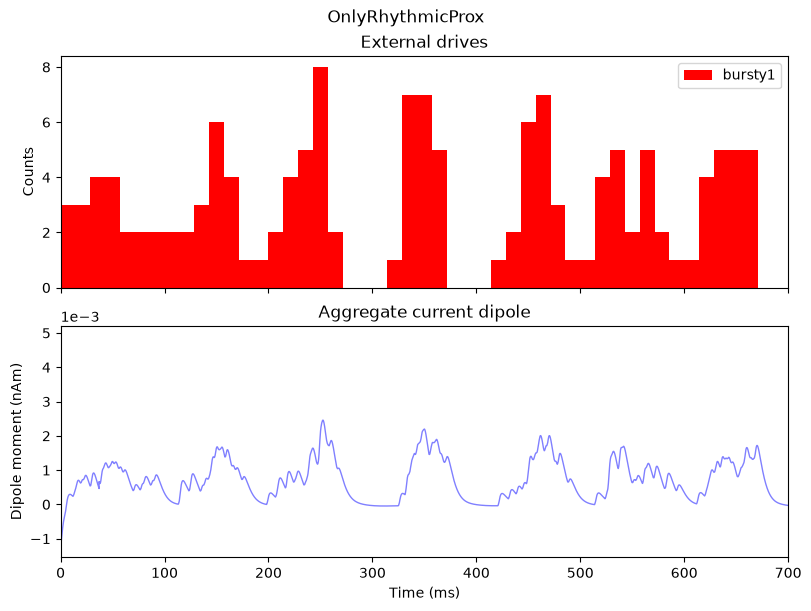

In [5]:
with MPIBackend(n_procs=n_procs):
    dpls_prox = simulate_dipole(net_prox, tstop=tstop, n_trials=1)

# Alternative if MPI is not installed:
# with JoblibBackend(n_jobs=n_procs):
#     dpls_prox = simulate_dipole(net_prox, tstop=tstop, n_trials=1)

_ = plot_drive_and_dipole(net_prox, dpls_prox, title='OnlyRhythmicProx')

As in the GUI's Figure 7, a burst of proximal input spikes is provided to
the network at a rate of ~10 Hz (i.e., every 100 ms), shown in the red
histogram. Due to the stochastic nature of the inputs (`tstart_std` and
`burst_std`), there is some variability in the timing of the input
bursts. The ~10 Hz bursts of proximal drive induce current flow **up**
the pyramidal neuron dendrites, increasing the dipole signal above the 0
nAm baseline, before relaxing back to zero approximately every 100 ms.

### 4.3 Visualize the spectrogram of the net current dipole

We now add the time-frequency spectrogram, using the 5-40 Hz frequency
range set in Section 3 above (c.f. GUI Figure 8).

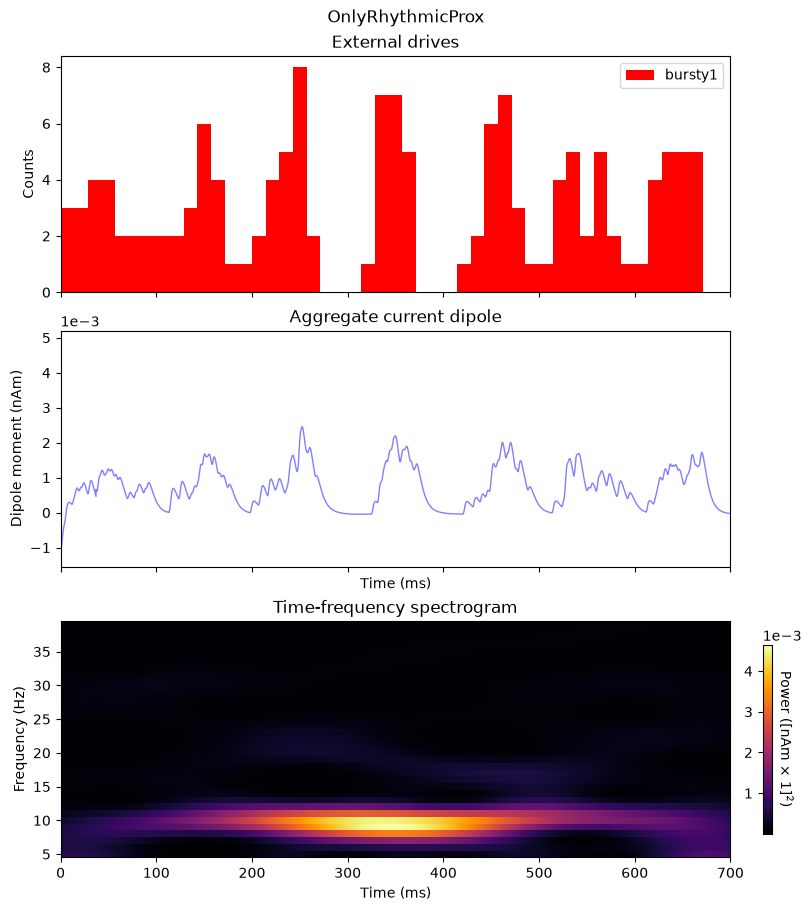

In [6]:
_ = plot_drive_dipole_spectrogram(net_prox, dpls_prox, title='OnlyRhythmicProx')

The bottom panel shows a high-power, continuous 10 Hz signal, as in the
GUI tutorial. Note that the strength of the proximal drive was titrated
to be subthreshold: our simulated cortical cells do not spike here. This
exploration with a proximal drive alone does not, by itself, reproduce
the waveform and spectral features of the recorded SI data. Next, we
explore the impact of rhythmic *distal* inputs alone.

## 5. Simulating Rhythmic Distal Inputs: Alpha Only

### 5.1 Define and view our distal input drive

This is the API equivalent of loading `OnlyRhythmicDist.json`. We
instantiate a fresh network and add a single rhythmic drive named
`bursty2` targeting the **distal** projection pathway. Notice that these
parameters are identical to the proximal drive above, except for the
`synaptic_delays` (which are longer and equal across cell types for the
distal pathway) and the `event_seed`.

In [7]:
net_dist = jones_2009_model()

weights_ampa_dist = {'L2_pyramidal': 5.4e-5, 'L5_pyramidal': 5.4e-5}
syn_delays_dist = {'L2_pyramidal': 5.0, 'L5_pyramidal': 5.0}

net_dist.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist, synaptic_delays=syn_delays_dist,
    event_seed=284)

net_dist.external_drives['bursty2']

<External drive 'bursty2'
drive class: bursty
target location: distal
target cell types: ['L2_pyramidal', 'L5_pyramidal']
number of drive cells: 10
cell-specific: False
dynamic parameters:
	tstart: 50.0
	tstart_std: 0.0
	tstop: None
	burst_rate: 10.0
	burst_std: 20.0
	numspikes: 2
	spike_isi: 10>

We now run the simulation and visualize the dipole and spectrogram
together (c.f. GUI Figures 10 and 11).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


numprocs=7
[pop-os][[63746,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[63746,1],0][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] U

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


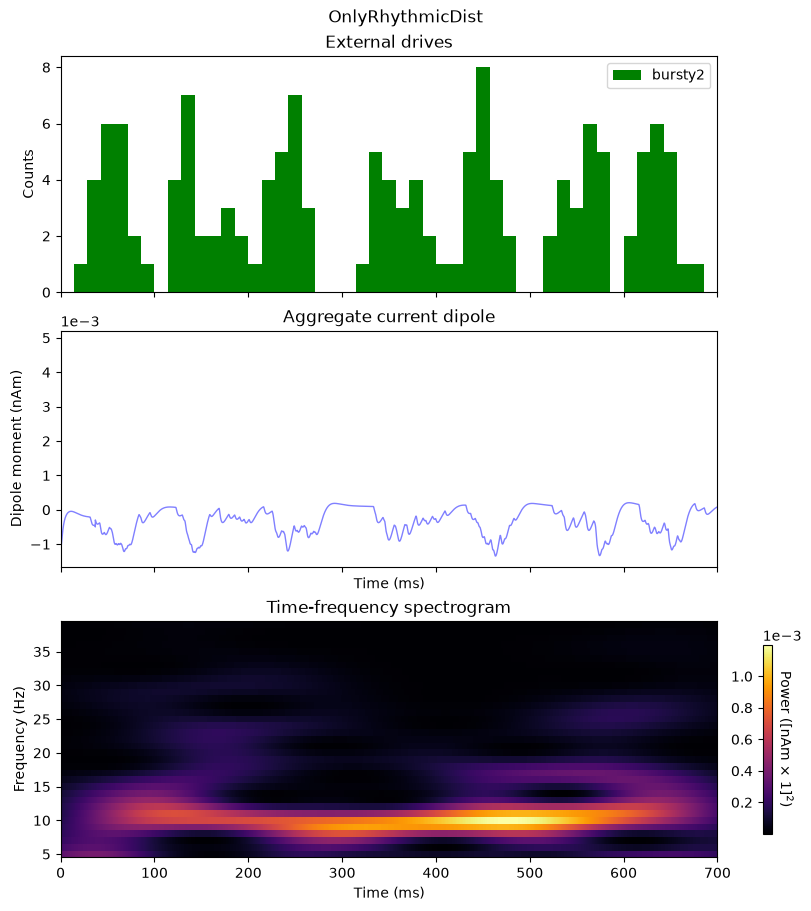

In [8]:
with MPIBackend(n_procs=n_procs):
    dpls_dist = simulate_dipole(net_dist, tstop=tstop, n_trials=1)

_ = plot_drive_dipole_spectrogram(net_dist, dpls_dist, title='OnlyRhythmicDist')

As shown in the green histogram, a burst of distal input spikes is
provided to the network at ~10 Hz. The ~10 Hz bursts of distal input
induce current flow **down** the pyramidal neuron dendrites, decreasing
the dipole signal below the 0 nAm baseline, before relaxing back to zero
approximately every 100 ms -- the opposite polarity compared with the
proximal-only simulation. As with the proximal drive, the distal drive
strength was titrated to be subthreshold. While instructional, this
simulation also does not reproduce the waveform and spectral features of
the experimental data. Next, we combine **both** rhythmic drives.

## 6. Simulating Combined Rhythmic Proximal and Distal Inputs: Alpha/Beta Complex

### 6.1 Define and view network drives

This is the API equivalent of loading `AlphaAndBeta.json`. All drive
parameters are the same as in Sections 4 and 5 above (except for the
random `event_seed`s), but now **both** the proximal (`bursty1`) and
distal (`bursty2`) drives are added to the same network, both starting
at `tstart=50` ms so that they arrive nearly synchronously to the network
on each ~10 Hz cycle.

In [9]:
net_ab = jones_2009_model()

net_ab.add_bursty_drive(
    'bursty1', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=283)

net_ab.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist, synaptic_delays=syn_delays_dist,
    event_seed=294)

### 6.2 Run the simulation and visualize the net current dipole

Because the drives are stochastic, sometimes the proximal and distal
bursts will arrive together and sometimes there will be a slight delay
between them. As described further below, this stochasticity creates
intermittent alpha and beta events (c.f. GUI Figures 13 and 14).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


[pop-os][[3369,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[3369,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reac

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


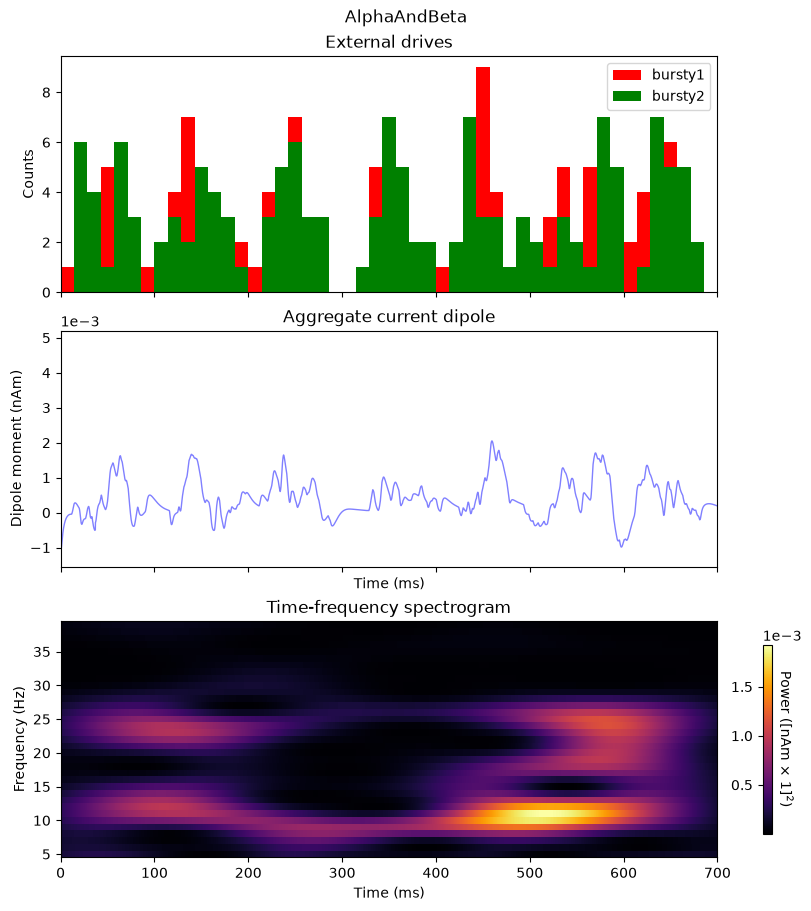

In [10]:
with MPIBackend(n_procs=n_procs):
    dpls_ab = simulate_dipole(net_ab, tstop=tstop, n_trials=1)

_ = plot_drive_dipole_spectrogram(net_ab, dpls_ab, title='AlphaAndBeta')

Bursts of both proximal (red) and distal (green) input spikes are
provided to the network at ~10 Hz. Due to the stochastic nature of the
inputs, there is variability in the timing and duration of the bursts:
sometimes they arrive at the same time, sometimes with a slight offset.
As a result, intermittent, transient alpha and beta events emerge in the
spectrogram. Alpha events occur when the inputs arrive slightly
out-of-phase; beta events occur when the burst inputs arrive more
synchronously, cutting the oscillation period roughly in half. The
current dipole signal now oscillates above *and* below 0 nAm, unlike the
proximal- or distal-only simulations, qualitatively matching the
experimental data.

### 6.3 Viewing network spiking activity

Importantly, the strength of the proximal and distal inputs above was
titrated to be **subthreshold**. We can verify this directly by viewing
the spiking rastergram (c.f. GUI's `Drive-Spikes (2x1)` layout, Figure
20).

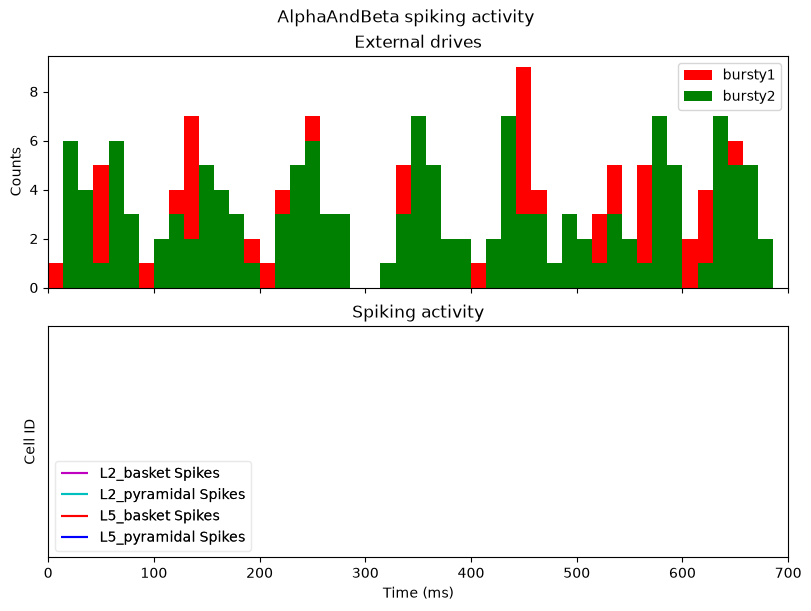

In [11]:
_ = plot_drive_and_spike_raster(net_ab, title='AlphaAndBeta spiking activity')

As in the GUI, the bottom panel is empty: there is no spiking produced by
any cell in the network. The alpha and beta events above are indeed
produced through purely subthreshold processes.

### 6.4 Simulating and averaging multiple trials with jittered start times

This is the API equivalent of loading `AlphaAndBetaJitter50.json`. As
described in Section 1 of the GUI tutorial, our simulation goal was to
study mechanisms that reproduce features of *spontaneous* alpha and beta
rhythms observed in un-averaged data, where alpha and beta components are
transient and intermittent. Here, we show that averaging several
simulation "trials" (each an independent 700 ms epoch of spontaneous
activity) with a jittered drive start time creates the impression of a
more continuous oscillation.

The only difference from the `AlphaAndBeta` parameters above is that
`tstart_std` for both drives is increased from `0` to `50` ms (c.f. GUI's
`Start time dev (ms)`). We also increase the number of trials
(`n_trials`) from `1` to `3` (c.f. GUI's `Trials` parameter in the
`Simulation` tab), which runs 3 independent simulations, each with
different randomized initial conditions for the drives.

In [12]:
net_jitter = jones_2009_model()

net_jitter.add_bursty_drive(
    'bursty1', tstart=50.0, tstart_std=50.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=274)

net_jitter.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=50.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist, synaptic_delays=syn_delays_dist,
    event_seed=284)

with MPIBackend(n_procs=n_procs):
    dpls_jitter = simulate_dipole(net_jitter, tstop=tstop, n_trials=3)

MPI will run 3 trial(s) sequentially by distributing network neurons over 7 processes.


[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[55626,1],0][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to fi

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 3: 650.0 ms...


Trial 3: 660.0 ms...


Trial 3: 670.0 ms...


Trial 3: 680.0 ms...


Trial 3: 690.0 ms...


`dpls_jitter` is now a list of 3 `Dipole` objects, one per trial.
`plot_tfr_morlet()` accepts a list of dipoles directly: it computes the
spectrogram power separately for each trial and then averages the power
across trials, exactly matching the accumulation process described in
the GUI tutorial (spectrogram values are strictly positive, so
non-time-locked alpha/beta events accumulate without cancelling out).
Similarly, `plot_dipole(..., average=True)` overlays the trial-averaged
waveform, and `plot_spikes_hist()` aggregates the drive histograms across
all trials by default.

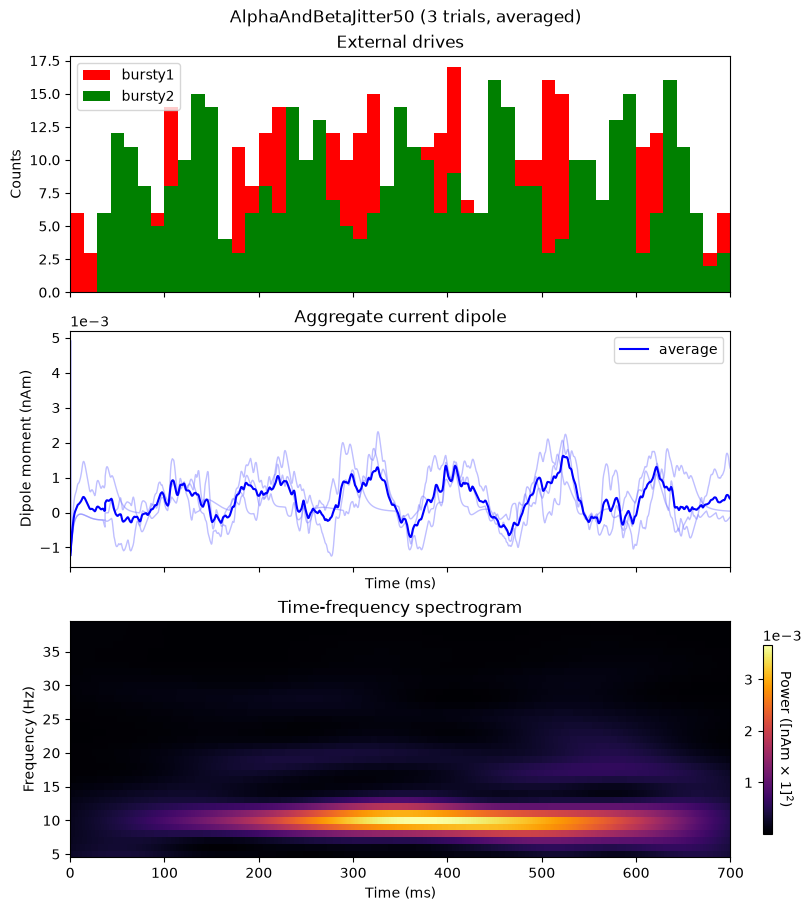

In [13]:
_ = plot_drive_dipole_spectrogram(net_jitter, dpls_jitter,
                               title='AlphaAndBetaJitter50 (3 trials, averaged)')

Notice that the input histograms for distal (green) and proximal (red)
input, accumulated across the 3 trials, now show little rhythmicity due
to the jitter in the rhythmic input start times across trials
(`tstart_std=50`), in addition to jitter from the inherent burst
variance (`burst_std=20`). This averaged simulation data exhibits
oscillations that appear more continuous than the single-trial example
in Section 6.2 above, and shows relatively more alpha than beta power:
less synchrony between the two drives implies less chance of the signal
going both up and down the dendrites simultaneously.

### 6.5 Exercises for further exploration

Try decreasing or increasing `n_trials` in the simulation above to see
how these changes impact the continuity of alpha/beta power over time.

## 7. Adjusting Parameters

Parameter adjustments are key to developing and testing hypotheses about
the circuit origin of your own low-frequency rhythmic data. Here, we walk
through examples of how adjusting the "Rhythmic Proximal/Distal Input"
drive parameters impacts the alpha and beta rhythms described above. Each
example below starts from the same `AlphaAndBeta` configuration used in
Section 6 (`event_seed=283` for `bursty1`, `event_seed=294` for
`bursty2`, both with `tstart_std=0`), with a single parameter changed.

### 7.1 Increasing the strength and synchrony of the distal drive increases beta activity

We saw in Section 6.2 that the relative timing of proximal and distal
inputs determines whether alpha or beta events emerge. Another factor
that increases the prevalence of beta activity is the strengthened
synchrony of the distal drive. Beta activity increases with a stronger,
more synchronous subthreshold distal drive, where the beta frequency is
set by the duration of the driving bursts (~50 ms). The strength is
controlled by the postsynaptic conductance (`weights_ampa`), and the
synchrony is controlled by `burst_std`. Here we:

* Decrease `burst_std` of the distal drive from `20` to `10` ms.
* Increase `weights_ampa` of the distal drive to both `L2_pyramidal` and
  `L5_pyramidal` from `5.4e-5` to `6e-5`.

Both changes push a greater amount of current flow down the pyramidal
neuron dendrites, more synchronously.

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


[pop-os][[31183,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[31183,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to fi

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


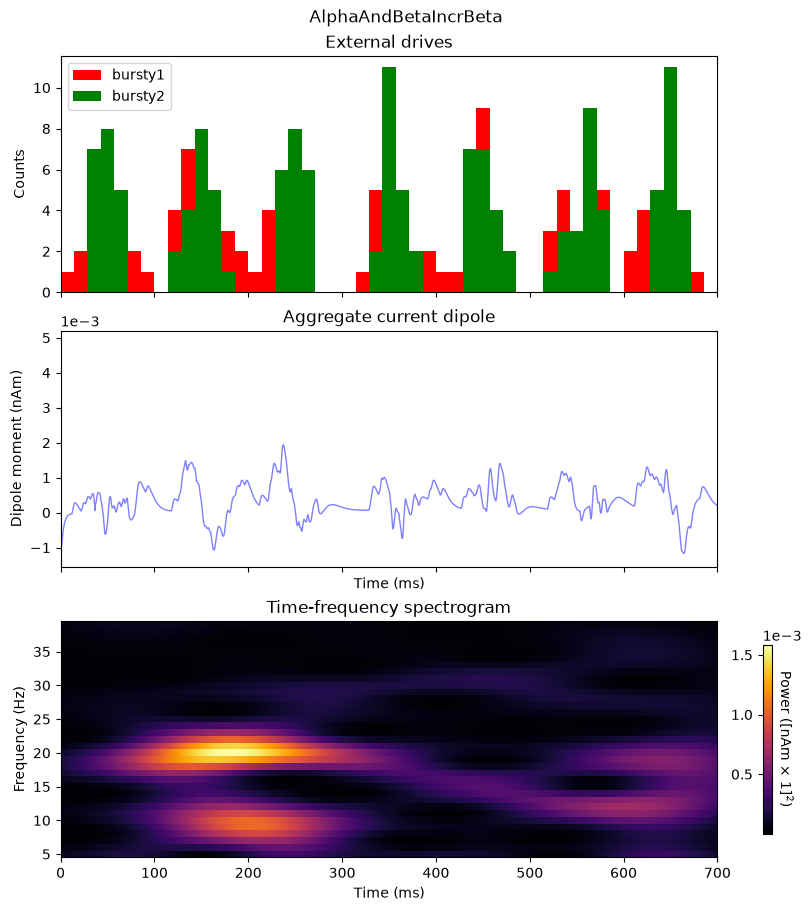

In [14]:
net_incr_beta = jones_2009_model()

net_incr_beta.add_bursty_drive(
    'bursty1', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=283)

weights_ampa_dist_strong = {'L2_pyramidal': 6e-5, 'L5_pyramidal': 6e-5}
net_incr_beta.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=10.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist_strong, synaptic_delays=syn_delays_dist,
    event_seed=294)

with MPIBackend(n_procs=n_procs):
    dpls_incr_beta = simulate_dipole(net_incr_beta, tstop=tstop, n_trials=1)

_ = plot_drive_dipole_spectrogram(net_incr_beta, dpls_incr_beta,
                               title='AlphaAndBetaIncrBeta')

The histogram profile of the distal input bursts (green) is narrower,
corresponding to more synchronous input than in the original
`AlphaAndBeta` simulation. The waveform also shows a sharper, downward
(negative) deflecting signal due to the stronger distal input. These
sharper deflections lead to increased ~20 Hz beta activity relative to
10 Hz alpha activity in the spectrogram, compared with Section 6.2. The
20 Hz frequency is set by the duration of the downward current flow,
here approximately 50 ms.

#### 7.1.1 Exercise for further exploration

Try changing the frequency of the rhythmic distal drive from 10 Hz to 20
Hz by setting `burst_rate`. Try other frequencies for the proximal and
distal rhythmic drives. How do the rhythms change? See how further
changes in `burst_std` affect the rhythms expressed.

### 7.2 Increasing the delay between proximal and distal inputs creates continuous alpha oscillations without beta activity

In addition to drive strength and synchrony, the relative *timing*
between proximal and distal inputs is an important factor in determining
the relative alpha and beta expression in the model. Here we demonstrate
that out-of-phase 10 Hz burst inputs can produce continuous alpha
activity *without* any beta events, by increasing the proximal drive's
`tstart` from `50` to `100` ms. Since the distal input still starts at
`tstart=50` ms, the two drives will now arrive to the network, on
average, a half-cycle out of phase (i.e., in antiphase, every 50 ms).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


numprocs=7
[pop-os][[61079,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],5][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],3][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],3][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],2][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[61079,1],4][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] U

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


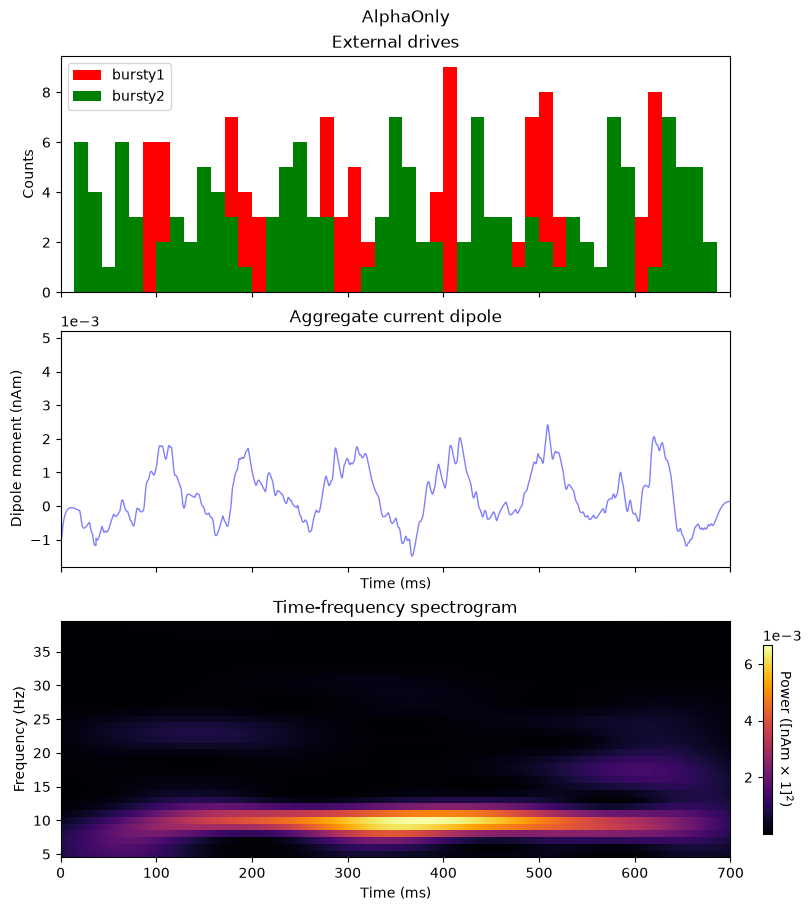

In [15]:
net_alpha_only = jones_2009_model()

net_alpha_only.add_bursty_drive(
    'bursty1', tstart=100.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=283)

net_alpha_only.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist, synaptic_delays=syn_delays_dist,
    event_seed=294)

with MPIBackend(n_procs=n_procs):
    dpls_alpha_only = simulate_dipole(net_alpha_only, tstop=tstop, n_trials=1)

_ = plot_drive_dipole_spectrogram(net_alpha_only, dpls_alpha_only,
                               title='AlphaOnly')

The histogram profile of the proximal (red) and distal (green) input
bursts are generally half a cycle out-of-phase (antiphase). This
alternation of proximal, followed by distal, drive induces alternating
subthreshold current flow up and down the pyramidal neuron dendrites,
creating a continuous alpha oscillation in the current dipole waveform
that oscillates around 0 nAm. The corresponding spectrogram shows
continuous, nearly-pure alpha activity, in contrast to the intermittent
alpha and beta seen in Section 6.2. This type of strong alpha activity
is similar to what might be observed over occipital cortex during
eyes-closed conditions.

#### 7.2.1 Exercise for further exploration

Try changing the delay between the proximal and distal drives by varying
amounts (i.e., other values of `tstart`). What happens to the rhythm
expressed? Can you create a simulation where other frequencies are
expressed? How is it created? Are the cells spiking or subthreshold?

### 7.3 Increasing the strength of the distal drive further creates high-frequency responses due to induced spiking activity

In all simulations so far, the strength of the rhythmic proximal and
distal inputs was chosen so that the simulated cells remained
subthreshold (no spiking). We now demonstrate what happens when the
distal drive strength is increased far enough to induce spikes. Instead
of subthreshold alpha/beta events, the dipole signal becomes dominated by
higher-frequency events created by spiking activity. This type of
activity is not typically observed in MEG or EEG data, supporting the
notion that alpha/beta rhythms are created through subthreshold
processes.

We increase `weights_ampa` of the distal drive to both `L2_pyramidal` and
`L5_pyramidal` from `5.4e-5` to `4e-4` (note the change in the exponent!),
and widen the spectrogram frequency range from 5-40 Hz to 5-120 Hz
(c.f. GUI's `Max Spectral Frequency (Hz)` change from `40` to `120`).

MPI will run 1 trial(s) sequentially by distributing network neurons over 7 processes.


[pop-os][[17256,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],3][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],2][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],3][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to find reachable pairing between local and remote interfaces
[pop-os][[17256,1],6][btl_tcp_proc.c:266:mca_btl_tcp_proc_create_interface_graph] Unable to fi

Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /home/wintermute/rep/brn/hnn-core/hnn_core/mod/x86_64/libnrnmech.so


[Done]
Trial 1: 0.03 ms...


Trial 1: 10.0 ms...


...

Trial 1: 650.0 ms...


Trial 1: 660.0 ms...


Trial 1: 670.0 ms...


Trial 1: 680.0 ms...


Trial 1: 690.0 ms...


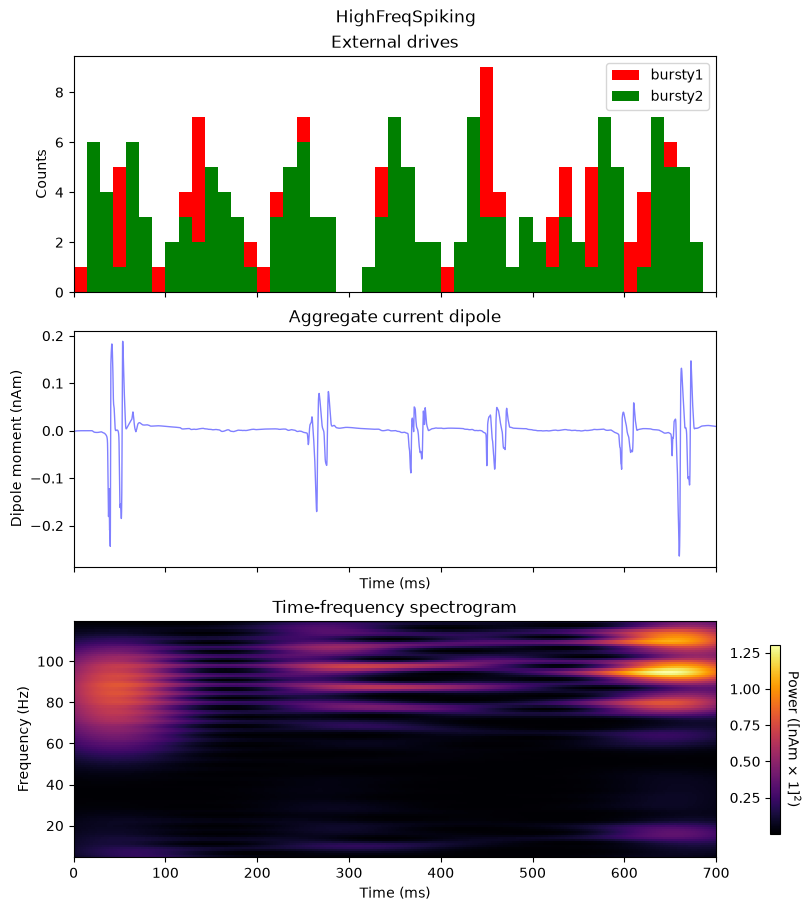

In [16]:
net_high_freq = jones_2009_model()

net_high_freq.add_bursty_drive(
    'bursty1', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='proximal',
    weights_ampa=weights_ampa_prox, synaptic_delays=syn_delays_prox,
    event_seed=283)

weights_ampa_dist_hf = {'L2_pyramidal': 4e-4, 'L5_pyramidal': 4e-4}
net_high_freq.add_bursty_drive(
    'bursty2', tstart=50.0, tstart_std=0.0, burst_rate=10.0, burst_std=20.0,
    numspikes=2, spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa_dist_hf, synaptic_delays=syn_delays_dist,
    event_seed=294)

with MPIBackend(n_procs=n_procs):
    dpls_high_freq = simulate_dipole(net_high_freq, tstop=tstop, n_trials=1)

freqs_wide = np.arange(5, 120, 1)  # widened "Max Spectral Frequency"
_ = plot_drive_dipole_spectrogram(net_high_freq, dpls_high_freq,
                               freqs=freqs_wide, title='HighFreqSpiking')

Because we greatly increased the postsynaptic conductance of the distal
driving spikes, the distal input now induces spiking activity in the
pyramidal neurons on several cycles of the drive, resulting in a sharp,
rapidly oscillating dipole waveform, and broadband ~60-120 Hz activity in
the spectrogram. Next, we verify that the neurons are indeed spiking by
overlaying the spiking rastergram on top of each layer's contribution to
the dipole signal, using `plot_spikes_raster(..., overlay_dipoles=True)`
(c.f. GUI's `Dipole Layers-Spikes (1x1)` layout, Figure 25).

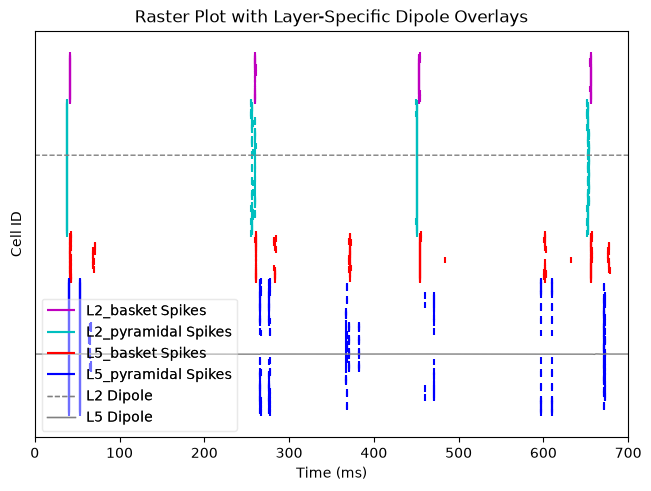

In [17]:
_ = net_high_freq.cell_response.plot_spikes_raster(
    dpl=dpls_high_freq, overlay_dipoles=True)
plt.show()

The grey lines correspond to each layer's contribution to the dipole
signal seen above, while the other colors represent spikes of each cell
population. Highly synchronous neuronal spiking in each population
coincides with the high-frequency events seen in the dipole signal. These
high-frequency waveforms are induced by the pyramidal neurons spiking,
which create rapid, back-propagating action potentials and repolarization
of the dendrites.

#### 7.3.1 Exercise for further exploration

View the contribution of Layer 2/3 and Layer 5 separately to the net
current dipole waveform (`layer='L2'` and `layer='L5'` in `plot_dipole()`
/ `plot_tfr_morlet()`) and compare with the spiking activity in each
population. How does each layer contribute? Try changing the *proximal*
input parameters instead of the distal input parameters -- can you elicit
high-frequency spiking using proximal input changes only? Finally, try
adjusting one of the parameters regulating the local network connections
(e.g. via `net.connectivity`, not covered in this tutorial). What
happens?

## References

1. Jones, S. R. et al. Quantitative analysis and biophysically realistic
   neural modeling of the MEG mu rhythm: rhythmogenesis and modulation of
   sensory-evoked responses. *J. Neurophysiol.* 102, 3554-3572 (2009).
2. Ziegler, D. A. et al. Transformations in oscillatory activity and
   evoked responses in primary somatosensory cortex in middle age: A
   combined computational neural modeling and MEG study. *NeuroImage* 52,
   897-912 (2010).
3. Sherman, M. A. et al. Neural mechanisms of transient neocortical beta
   rhythms: Converging evidence from humans, computational modeling,
   monkeys, and mice. *Proc. Natl. Acad. Sci.* 113, E4885-E4894 (2016).
4. Jones, S. R. When brain rhythms aren't 'rhythmic': implication for
   their mechanisms and meaning. *Curr. Opin. Neurobiol.* 40, 72-80
   (2016).
5. Jones, E. G. The thalamic matrix and thalamocortical synchrony.
   *Trends Neurosci.* 24, 595-601 (2001).
6. Hughes, S. W. & Crunelli, V. Thalamic mechanisms of EEG alpha rhythms
   and their pathological implications. *Neuroscientist* 11, 357-372
   (2005).
7. Zhu, Z. et al. The relationship between magnetic and
   electrophysiological responses to complex tactile stimuli. *BMC
   Neurosci.* 10, 4 (2009).